Part 1: 

In [70]:
import pandas as pd
import statsmodels.formula.api as smf

penguins = pd.read_csv("/Users/ciarrabarn/Downloads/penguins.csv")
model1 = smf.ols("body_mass_g ~ flipper_length_mm + C(sex) + C(species)",
data=penguins).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     534.0
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          3.37e-142
Time:                        23:40:10   Log-Likelihood:                -2364.4
No. Observations:                 333   AIC:                             4739.
Df Residuals:                     328   BIC:                             4758.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                -365.8174    532.050     -0.688      0.492   -1412.479     680.844
C(sex)[T.male]            530.3811     37.810     14.027      0.000     456.000     604.762
C(species)[T.Chinstrap]   -87.6345     46.347     -1.891      0.060    -178.810       3.541
C(species)[T.Gentoo]      836.2600     85.185      9.817      0.000     668.681    1003.839
flipper_length_mm          20.0249      2.846      7.037      0.000      14.427      25.623
==============================================================================
Omnibus:                        1.575   Durbin-Watson:                   2.097
Prob(Omnibus):                  0.455   Jarque-Bera (JB):                1.556
Skew:                           0.094   Prob(JB):                        0.459
Kurtosis:                       2.723   Cond. No.                     6.69e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.69e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

1. The coeffient for intercept is -365.8174, C(sex)[T.male] is  530.38, C(species)[T.Gentoo] is 836.26, flipper_length_mm id 20.03. The R^2 is 0.8669 so that is about 86.69%. The referenece level is female and reference is Adelie. The coffeiecent being 836.26 means that its holding sex and flipper length constant and Gentoo penguins are predicted to weight 836 more than Adelie. 

In [71]:
penguins_clean = penguins[["body_mass_g","flipper_length_mm", "sex", "species"]].dropna()

In [72]:
X = penguins_clean[["flipper_length_mm", "sex", "species"]]
y = penguins_clean["body_mass_g"]

In [73]:
X_dummy = pd.get_dummies(X, columns=["sex", "species"],drop_first=True, dtype=int)
X_dummy.head()

,flipper_length_mm,sex_male,species_Chinstrap,species_Gentoo
0,181.0,1,0,0
1,186.0,0,0,0
2,195.0,0,0,0
4,193.0,0,0,0
5,190.0,1,0,0


In [74]:
from sklearn.linear_model import LinearRegression
model2 = LinearRegression()
model2.fit(X_dummy, y) 

print("Intercept:", model2.intercept_)
print("Coefficients:")
print(pd.Series(model2.coef_, index=X_dummy.columns))
print("R-squared:", model2.score(X_dummy, y))


Intercept: -365.81744976158825
Coefficients:
flipper_length_mm     20.024915
sex_male             530.381094
species_Chinstrap    -87.634478
species_Gentoo       836.260008
dtype: float64
R-squared: 0.866888356233088


2b. You can use statsmodels if you want confidence intervals for the coefficents. 

In [75]:
X_full = pd.get_dummies(X,columns=["sex", "species"],drop_first=False,dtype=int)
X_full.head() 


,flipper_length_mm,sex_female,sex_male,species_Adelie,species_Chinstrap,species_Gentoo
0,181.0,0,1,1,0,0
1,186.0,1,0,1,0,0
2,195.0,1,0,1,0,0
4,193.0,1,0,1,0,0
5,190.0,0,1,1,0,0


There are 2 columns for sex and 3 columns for species. 

In [ ]:
model3=LinearRegression(fit_intercept=True)
model3.fit(X_full, y) 
model3.score(X_full, y)

0.8668883562330879

In [76]:
pred2 = model2.predict(X_dummy)
pred3 = model3.predict(X_full)

import numpy as np
np.allclose(pred2, pred3)

True

In [77]:
print(model3.intercept_)
pd.Series(model3.coef_,index=X_full.columns)

148.91494089133266


flipper_length_mm     20.024915
sex_female          -265.190547
sex_male             265.190547
species_Adelie      -249.541843
species_Chinstrap   -337.176321
species_Gentoo       586.718165
dtype: float64

3b. These are not the same as Question 2. 

In [79]:
coef3 = pd.Series(model3.coef_, index=X_full.columns)
coef3 

print("Chinstrap - Adelie:",coef3["species_Chinstrap"] - coef3["species_Adelie"])
print("Gentoo - Adelie:",coef3["species_Gentoo"] - coef3["species_Adelie"])
print("Male - Female:",coef3["sex_male"] - coef3["sex_female"])

Chinstrap - Adelie: -87.63447791888183
Gentoo - Adelie: 836.260008147463
Male - Female: 530.3810944866987


3c. The individuals are not teh same but when I calculate the difference bwteen Chinstrap and Adelie, Gentoo - Adelie, and male - female the difference match the coefficent from the dummy model in Question 2. 


3d. The way you encode categories changes how the coefficients are represented and interepreted. 

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import pandas as pd

penguins_clean = penguins[["body_mass_g", "flipper_length_mm", "sex", "species"]].dropna()

X = penguins_clean[["flipper_length_mm", "sex", "species"]]
y = penguins_clean["body_mass_g"]

preprocessor = ColumnTransformer([("num", "passthrough", ["flipper_length_mm"]),("cat", OneHotEncoder(drop="first"), ["sex", "species"])])
pipeline = Pipeline([("preprocessor", preprocessor),("model", LinearRegression())])
pipeline.fit(X, y)

feature_names = preprocessor.get_feature_names_out()
coefficients = pipeline.named_steps["model"].coef_

print("Intercept:", pipeline.named_steps["model"].intercept_)
print("\nCoefficients:")
print(pd.Series(coefficients, index=feature_names))

Intercept: -365.81744976158825

Coefficients:
num__flipper_length_mm     20.024915
cat__sex_male             530.381094
cat__species_Chinstrap    -87.634478
cat__species_Gentoo       836.260008
dtype: float64


4a. The pipeline produced the same columns and coefficients as Question 2. 

In [81]:
new_penguin = pd.DataFrame({"flipper_length_mm": [215],"sex": ["male"],"species": ["Gentoo"]}) 
prediction = pipeline.predict(new_penguin)
prediction

array([5306.18047038])

In [14]:
-365.817 + (20.025 * 215) + 530.381 + 836.260

5306.1990000000005

4b. The predicted body mass is 5,306 grams. For my calculation I did intercept + flipper effect + male effect + Gentoo effect from Question 1 which gave the same result. 

Part 2

In [82]:
import os
print(os.getcwd())
print(os.listdir())

/Users/ciarrabarn/DS6021_F26/homework/assignments
['Lab4 DS6021.ipynb', 'DS6021 F26 Lab Activity 1.pdf', 'DS6021 F26 Lab Activity 0.pdf', 'DS6021 F26 Lab Activity 2.pdf', 'DS6021 F26 Lab Activity 3.pdf', 'DS6021 F26 Lab Activity 4.pdf']


In [83]:
import pandas as pd
penguins = pd.read_csv("/Users/ciarrabarn/Downloads/penguins.csv")

In [84]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np 

penguins_part2 = penguins[["body_mass_g", "flipper_length_mm", "bill_length_mm", "bill_depth_mm"]].dropna()

X_part2 = penguins_part2[ ["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]]
y_part2 = penguins_part2["body_mass_g"]

model_part2 = LinearRegression()
model_part2.fit(X_part2, y_part2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[50.27, 4.16,20.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['flipper_length_mm','bill_length_mm','bill_depth_mm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6425
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


1a. RFE would drop bill_length_mm first because it has the smallest absolute coefficient.

In [85]:
X_cm = X_part2.copy()
X_cm["bill_length_mm"] = X_cm["bill_length_mm"] / 10

model_cm = LinearRegression()
model_cm.fit(X_cm, y_part2)

coefficients_cm = pd.Series( model_cm.coef_,index=X_cm.columns)

print("Coefficients:")
print(coefficients_cm)
print("\nR-squared:", model_cm.score(X_cm, y_part2))
print("\nSmallest absolute coefficient:")
print(coefficients_cm.abs().sort_values())

pred_original = model_part2.predict(X_part2)
pred_cm = model_cm.predict(X_cm)

np.allclose(pred_original, pred_cm)

Coefficients:
flipper_length_mm    50.269222
bill_length_mm       41.618205
bill_depth_mm        20.049533
dtype: float64

R-squared: 0.7614704841272493

Smallest absolute coefficient:
bill_depth_mm        20.049533
bill_length_mm       41.618205
flipper_length_mm    50.269222
dtype: float64


True

1b. After converting bill length from millimeters to centimeters, its coefficient increased from 4.16 to 41.62. The other coefficients  R^2 and predictions stayed the same. RFE would now drop bill depth first because it has the smallest absolute coefficient. 

In [86]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import pandas as pd

model_std = make_pipeline(StandardScaler(),LinearRegression())
model_std.fit(X_part2, y_part2)
coefficients_std = pd.Series(model_std.named_steps["linearregression"].coef_,index=X_part2.columns)

print("Standardized coefficients:")
print(coefficients_std)

Standardized coefficients:
flipper_length_mm    705.837207
bill_length_mm        22.688564
bill_depth_mm         39.535753
dtype: float64


2a. 1 unit = 1 standard deviation so the flipper length coefficient tells us how much body mass changes when flipper length increases by 1 standard deviation, while the other variables stay the same. 

In [20]:
ranking_std = coefficients_std.abs().sort_values(ascending=False)

print("Ranking by absolute coefficient:")
print(ranking_std)

print("\nRFE would drop first:")
print(ranking_std.index[-1])

Ranking by absolute coefficient:
flipper_length_mm    705.837207
bill_depth_mm         39.535753
bill_length_mm        22.688564
dtype: float64

RFE would drop first:
bill_length_mm


In [87]:
X_cm_std = X_part2.copy()

X_cm_std["bill_length_mm"] = X_cm_std["bill_length_mm"] / 10

model_cm_std = make_pipeline(StandardScaler(),LinearRegression())

model_cm_std.fit(X_cm_std, y_part2)

coefficients_cm_std = pd.Series(model_cm_std.named_steps["linearregression"].coef_,index=X_cm_std.columns)

print("Standardized coefficients after converting bill length to cm:")
print(coefficients_cm_std)
print("\nRanking:")
print(coefficients_cm_std.abs().sort_values(ascending=False))

Standardized coefficients after converting bill length to cm:
flipper_length_mm    705.837207
bill_length_mm        22.688564
bill_depth_mm         39.535753
dtype: float64

Ranking:
flipper_length_mm    705.837207
bill_depth_mm         39.535753
bill_length_mm        22.688564
dtype: float64


2b. Flipper length is the most important feature, followed by bill depth, then bill length. RFE would remove bill length first because it has the smallest coefficient. Changing bill length from millimeters to centimeters does not change the ranking because StandardScaler puts all predictors on the same scalee

In [88]:
from sklearn.preprocessing import RobustScaler

model_robust = make_pipeline(RobustScaler(),LinearRegression())
model_robust.fit(X_part2, y_part2)
coefficients_robust = pd.Series(
model_robust.named_steps["linearregression"].coef_,
index=X_part2.columns)

print("RobustScaler coefficients:")
print(coefficients_robust)
print("\nRanking:")
print(coefficients_robust.abs().sort_values(ascending=False))

RobustScaler coefficients:
flipper_length_mm    1156.192098
bill_length_mm         38.600885
bill_depth_mm          62.153553
dtype: float64

Ranking:
flipper_length_mm    1156.192098
bill_depth_mm          62.153553
bill_length_mm         38.600885
dtype: float64


In [89]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

model_minmax = make_pipeline(MinMaxScaler(),LinearRegression())
model_minmax.fit(X_part2, y_part2)
coefficients_minmax = pd.Series(model_minmax.named_steps["linearregression"].coef_,index=X_part2.columns)

print("MinMaxScaler coefficients:")
print(coefficients_minmax)

MinMaxScaler coefficients:
flipper_length_mm    2965.884077
bill_length_mm        114.450063
bill_depth_mm         168.416078
dtype: float64


In [90]:
comparison = pd.DataFrame({"StandardScaler": coefficients_std,"MinMaxScaler": coefficients_minmax,"RobustScaler": coefficients_robust})
print(comparison)

                   StandardScaler  MinMaxScaler  RobustScaler
flipper_length_mm      705.837207   2965.884077   1156.192098
bill_length_mm          22.688564    114.450063     38.600885
bill_depth_mm           39.535753    168.416078     62.153553


2c. All three scalers give the same ranking: flipper length first, bill depth second, and bill length third. The coefficient values are different because each scaler measures the variables differently. StandardScaler uses standard deviation, MinMaxScaler uses the min to max range, and RobustScaler uses the iqr range. 

In [91]:
model_center = make_pipeline(StandardScaler(with_std=False),LinearRegression())
model_center.fit(X_part2, y_part2)

coefficients_center = pd.Series(model_center.named_steps["linearregression"].coef_,index=X_part2.columns)

print("Centered coefficients:")
print(coefficients_center)
print("\nR-squared:")
print(model_center.score(X_part2, y_part2))

Centered coefficients:
flipper_length_mm    50.269222
bill_length_mm        4.161820
bill_depth_mm        20.049533
dtype: float64

R-squared:
0.7614704841272493


2d. Centering changes where zero is but it doesn't  change the units. The predictors are still measured in millimeters, so the slope coefficients stay the same as the original model 

3. 

In [58]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [92]:
model_original = LinearRegression()
model_original.fit(X_part2, y_part2)

coef_original = model_original.coef_
intercept_original = model_original.intercept_
r2_original = model_original.score(X_part2, y_part2)
pred_original = model_original.predict(X_part2)

X_cm = X_part2.copy()
X_cm["bill_length_mm"] = X_cm["bill_length_mm"] / 10

model_cm = LinearRegression()
model_cm.fit(X_cm, y_part2)

coef_cm = model_cm.coef_
intercept_cm = model_cm.intercept_
r2_cm = model_cm.score(X_cm, y_part2)
pred_cm = model_cm.predict(X_cm)

X_centered = X_part2 - X_part2.mean()

model_centered = LinearRegression()
model_centered.fit(X_centered, y_part2)

coef_centered = model_centered.coef_
intercept_centered = model_centered.intercept_
r2_centered = model_centered.score(X_centered, y_part2)
pred_centered = model_centered.predict(X_centered)

model_standard = make_pipeline(StandardScaler(),LinearRegression())
model_standard.fit(X_part2, y_part2)

coef_standard = model_standard.named_steps["linearregression"].coef_
intercept_standard = model_standard.named_steps["linearregression"].intercept_
r2_standard = model_standard.score(X_part2, y_part2)
pred_standard = model_standard.predict(X_part2)
model_minmax = make_pipeline(MinMaxScaler(),LinearRegression())
model_minmax.fit(X_part2, y_part2)

coef_minmax = model_minmax.named_steps["linearregression"].coef_
intercept_minmax = model_minmax.named_steps["linearregression"].intercept_
r2_minmax = model_minmax.score(X_part2, y_part2)
pred_minmax = model_minmax.predict(X_part2)

In [98]:
table3 = pd.DataFrame({"Model": ["Original units","Bill length in cm", 
    "Centered predictors","StandardScaler","MinMaxScaler"],
    "Coefficients": [
        coef_original,
        coef_cm,
        coef_centered,
        coef_standard,
        coef_minmax
    ],
    "Intercept": [
        intercept_original,
        intercept_cm,
        intercept_centered,
        intercept_standard,
        intercept_minmax
    ],
    "R2": [
        r2_original,
        r2_cm,
        r2_centered,
        r2_standard,
        r2_minmax
        
        
    ]
})
table3

,Model,Coefficients,Intercept,R2
0,Original units,"[50.269221638240424, 4.161820470411512, 20.049...",-6424.764698,0.76147
1,Bill length in cm,"[50.26922163824041, 41.618204704115186, 20.049...",-6424.764698,0.76147
2,Centered predictors,"[50.26922163824043, 4.1618204704115005, 20.049...",4201.754386,0.76147
3,StandardScaler,"[705.8372072960943, 22.688563925608914, 39.535...",4201.754386,0.76147
4,MinMaxScaler,"[2965.8840766561857, 114.45006293631606, 168.4...",2617.784745,0.76147


In [37]:
table3["Coefficients_changed"] = [
    False,
    not np.allclose(coef_cm, coef_original),
    not np.allclose(coef_centered, coef_original),
    not np.allclose(coef_standard, coef_original),
    not np.allclose(coef_minmax, coef_original)
]
table3["Intercept_changed"] = [
    False,
    not np.isclose(intercept_cm, intercept_original),
    not np.isclose(intercept_centered, intercept_original),
    not np.isclose(intercept_standard, intercept_original),
    not np.isclose(intercept_minmax, intercept_original)
]
table3["R2_changed"] = [
    False,
    not np.isclose(r2_cm, r2_original),
    not np.isclose(r2_centered, r2_original),
    not np.isclose(r2_standard, r2_original),
    not np.isclose(r2_minmax, r2_original)
]
table3["Predictions_changed"] = [
    False,
    not np.allclose(pred_cm, pred_original),
    not np.allclose(pred_centered, pred_original),
    not np.allclose(pred_standard, pred_original),
    not np.allclose(pred_minmax, pred_original)
]
table3

,Model,Coefficients,Intercept,R2,Coefficients_changed,Intercept_changed,R2_changed,Predictions_changed
0,Original units,"[50.269221638240424, 4.161820470411512, 20.049...",-6424.764698,0.76147,False,False,False,False
1,Bill length in cm,"[50.26922163824041, 41.618204704115186, 20.049...",-6424.764698,0.76147,True,False,False,False
2,Centered predictors,"[50.26922163824043, 4.1618204704115005, 20.049...",4201.754386,0.76147,False,True,False,False
3,StandardScaler,"[705.8372072960943, 22.688563925608914, 39.535...",4201.754386,0.76147,True,True,False,False
4,MinMaxScaler,"[2965.8840766561857, 114.45006293631606, 168.4...",2617.784745,0.76147,True,True,False,False


In [38]:
import statsmodels.api as sm
X_sm_original = sm.add_constant(X_part2)
sm_original = sm.OLS(
    y_part2,
    X_sm_original
).fit()
print(sm_original.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     359.7
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          8.19e-105
Time:                        23:09:26   Log-Likelihood:                -2526.7
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     338   BIC:                             5077.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -6424.7647    561.46

In [39]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_part2),
    columns=X_part2.columns,
    index=X_part2.index
)
X_sm_scaled = sm.add_constant(X_scaled)
sm_scaled = sm.OLS(
    y_part2,
    X_sm_scaled
).fit()
print(sm_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     359.7
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          8.19e-105
Time:                        23:09:49   Log-Likelihood:                -2526.7
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     338   BIC:                             5077.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              4201.7544     21.27

3b. The t-statistics and p-values stay the same after standardization, so the statistical significance does not change. The coefficients change because the predictors are measured on a different scale.The predictions and R^2 stay the same. This means scaling changes how we interpret the coefficients, but not the overall model results

In [42]:
X_log = np.log(X_part2)
model_log = LinearRegression()
model_log.fit(X_log, y_part2)
coef_log = model_log.coef_
intercept_log = model_log.intercept_
r2_log = model_log.score(X_log, y_part2)
pred_log = model_log.predict(X_log)

print("Log coefficients:", coef_log)
print("Intercept:", intercept_log)
print("R-squared:", r2_log)

Log coefficients: [9957.88050204  260.46791002  258.82811392]
Intercept: -50296.69719703897
R-squared: 0.7529680289105356


In [43]:
log_row = pd.DataFrame({
    "Model": ["Log predictors"],
    "Coefficients": [coef_log],
    "Intercept": [intercept_log],
    "R2": [r2_log],
    "Coefficients_changed": [
        not np.allclose(coef_log, coef_original)
    ],
    "Intercept_changed": [
        not np.isclose(intercept_log, intercept_original)
    ],
    "R2_changed": [
        not np.isclose(r2_log, r2_original)
    ],
    "Predictions_changed": [
        not np.allclose(pred_log, pred_original)
    ]
})
table3 = pd.concat(
    [table3, log_row],
    ignore_index=True
)
table3

,Model,Coefficients,Intercept,R2,Coefficients_changed,Intercept_changed,R2_changed,Predictions_changed
0,Original units,"[50.269221638240424, 4.161820470411512, 20.049...",-6424.764698,0.761470,False,False,False,False
1,Bill length in cm,"[50.26922163824041, 41.618204704115186, 20.049...",-6424.764698,0.761470,True,False,False,False
2,Centered predictors,"[50.26922163824043, 4.1618204704115005, 20.049...",4201.754386,0.761470,False,True,False,False
3,StandardScaler,"[705.8372072960943, 22.688563925608914, 39.535...",4201.754386,0.761470,True,True,False,False
4,MinMaxScaler,"[2965.8840766561857, 114.45006293631606, 168.4...",2617.784745,0.761470,True,True,False,False
5,Log predictors,"[9957.880502040613, 260.46791001709283, 258.82...",-50296.697197,0.752968,True,True,True,True


3c. The linear transformations changed the coefficients and intercept, but the R^2 and predictions stayed the same. Taking the log of the predictors changed the coefficients, predictions, and R^2. This is because a log transformation changes the shape of the relationship 

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

bike = pd.read_csv("/Users/ciarrabarn/DS6021_F26/data/bike-sharing-daily.csv")
bike.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


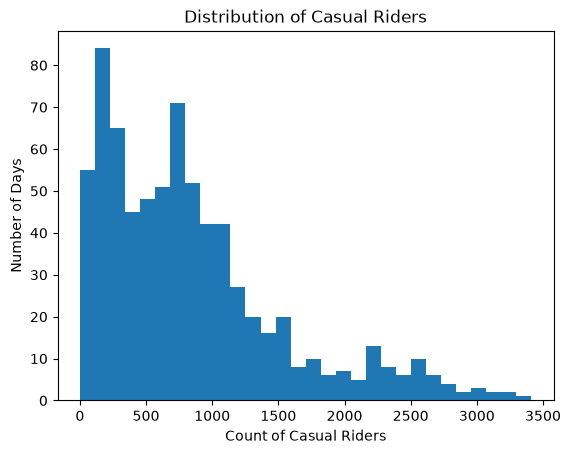

In [54]:
plt.hist(bike["casual"], bins=30)
plt.xlabel("Count of Casual Riders")
plt.ylabel("Number of Days")
plt.title("Distribution of Casual Riders")
plt.show()

4a. The distribution of casual riders is right skewed. Most days have lower counts of casual riders, while fewer days have very high counts. This creates a long tail on the right side 

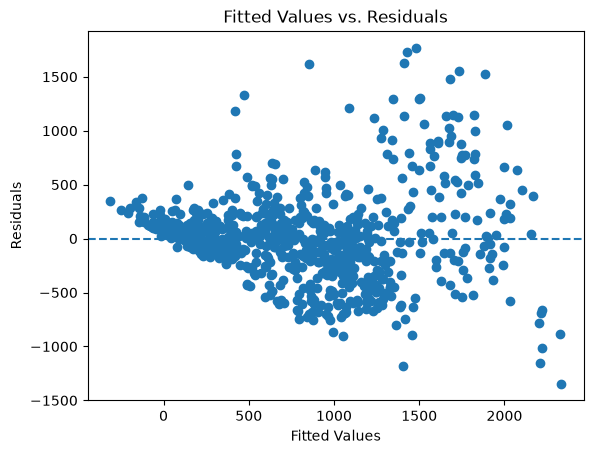

In [55]:
from sklearn.linear_model import LinearRegression
X_bike = bike[
    ["temp", "hum", "windspeed", "workingday"]
]
y_bike = bike["casual"]
bike_model = LinearRegression()
bike_model.fit(X_bike, y_bike)
fitted = bike_model.predict(X_bike)
residuals = y_bike - fitted

plt.scatter(fitted, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted Values vs. Residuals")
plt.show()

4b. The residuals are not randomly scattered around zero. The spread of the residuals increases as the fitted values increase. This suggests non constant variance and shows that the linear model does not fit the casual rider counts equally well across all fitted values

In [62]:
print((bike["casual"] == 0).sum())

0


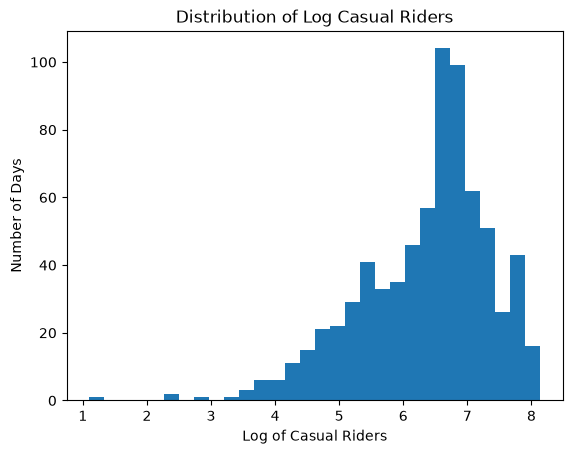

In [66]:
plt.hist(bike["log_casual"], bins=30)
plt.xlabel("Log of Casual Riders")
plt.ylabel("Number of Days")
plt.title("Distribution of Log Casual Riders")
plt.show()

In [67]:
X_bike = bike[["temp", "hum", "windspeed", "workingday"]]
y_log = bike["log_casual"]
bike_log_model = LinearRegression()
bike_log_model.fit(X_bike, y_log)
fitted_log = bike_log_model.predict(X_bike)
residuals_log = y_log - fitted_log

4c. After taking the log of casual riders, the data became less right skewed and more balanced. The residual plot also improved because the residuals are more evenly spread out 

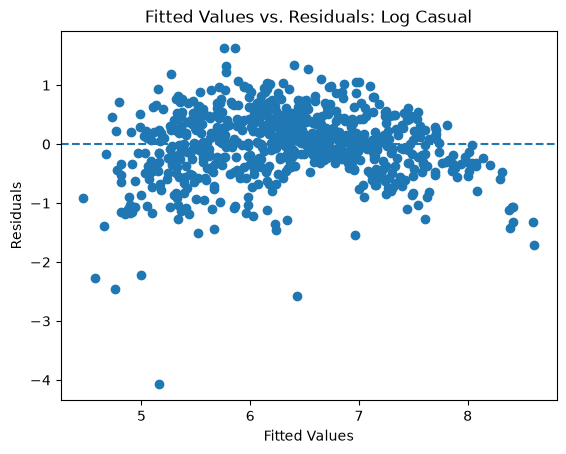

In [68]:
plt.scatter(fitted_log, residuals_log)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted Values vs. Residuals: Log Casual")
plt.show()

4d. Yes, the log transformation made sense because the original casual rider counts were strongly right skewed. The log made the histogram more balanced and the residuals more evenly spread. This helped reduce the skew and stabilize the wariance. This is different from Kepler’s Law where the log was used to make a nonlinear relationship more linear 

AI Disclosure:  

I used AI as a support tool to help me debug errors, understand problems in my code, and assist with writing portions of the code for this assignment. I also used the in- lass notebooks and examples provided by the professor as references to guide my work. I reviewed and tested the code to make sure I understood it and that it worked correctly.